<a href="https://colab.research.google.com/github/vidhi-sys/PyTorch_DeepLearning_TensorFlow/blob/main/MNIST_FASHION_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [42]:
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

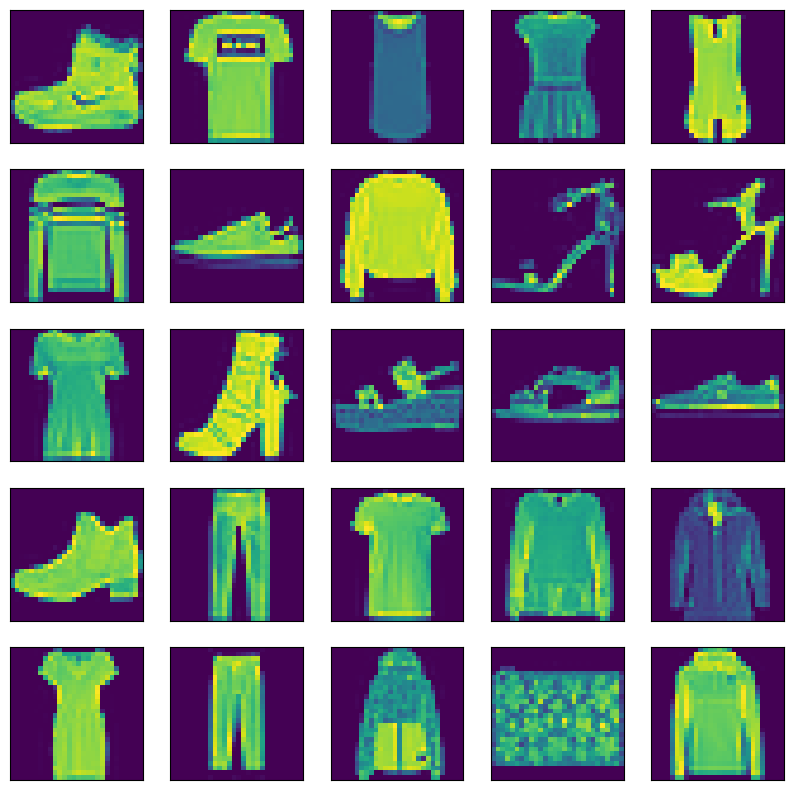

In [43]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
plt.show()

In [44]:
# Reshape and normalize images for Conv2D input
train_images = x_train.reshape((x_train.shape[0], 28, 28, 1)).astype('float32') / 255.0
test_images = x_test.reshape((x_test.shape[0], 28, 28, 1)).astype('float32') / 255.0

In [45]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Flatten(), # Flatten the output of the convolutional layers
    layers.Dense(10) # Add a Dense layer for classification with 10 output units for 10 classes
])

In [46]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        31,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,114 (340.29 KB)

 Trainable params: 87,114 (340.29 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, y_train, epochs=10,
                    validation_data=(test_images, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 87s 45ms/step - accuracy: 0.7897 - loss: 0.5878 - val_accuracy: 0.8715 - val_loss: 0.3632
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 45ms/step - accuracy: 0.8966 - loss: 0.2831 - val_accuracy: 0.8980 - val_loss: 0.2786
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 46ms/step - accuracy: 0.9158 - loss: 0.2329 - val_accuracy: 0.9114 - val_loss: 0.2537
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.9287 - loss: 0.1994 - val_accuracy: 0.9115 - val_loss: 0.2496
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 87s 46ms/step - accuracy: 0.9356 - loss: 0.1773 - val_accuracy: 0.9194 - val_loss: 0.2335
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.9459 - loss: 0.1529 - val_accuracy: 0.9113 - val_loss: 0.2458
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 45ms/step - accuracy: 0.9501 - loss: 0.1362 - val_accuracy: 0.9163 - val_loss: 0.2455
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 143s 45ms/step - accuracy: 0.953